In [1]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
from functools import partial
import math
import numpy as np

import jax
import jax.numpy as jnp

import doe
import doe.secret

import matplotlib.pyplot as plt

env: XLA_PYTHON_CLIENT_PREALLOCATE=false


In [2]:
with open('../config/parameters-123456789.yaml', 'r') as f:
    import yaml
    PARAMETERS = yaml.safe_load(f)

timestamps = jnp.linspace(0, 30, num=9 + 2)[1:-1]
SIGMA_NOISE = 0.025
TEMPERATURE_RANGE = (0.0, 100.0)

E_fixed = 0.5

CONCENTRATIONS = {
    'A': 3.0,
    'B': 3.0,
    'E': 3.0e-3
}

In [3]:
def initial_conditions(conditions):
    solutions = conditions[..., 0]
    temperature = conditions[..., 1]

    A0, B0 = solutions / 2, solutions / 2
    E = 1 - solutions
    A0 = CONCENTRATIONS['A'] * A0
    B0 = CONCENTRATIONS['B'] * B0
    E = CONCENTRATIONS['E'] * E

    return A0, B0, E, temperature

def euler(kinetics):
    @partial(jax.jit, static_argnames=('n', 'horizon'))
    def solve(conditions, n: int=1024, horizon: float=30.0):
        A0, B0, E, temperature = initial_conditions(conditions)
        dt = horizon / n
    
        def euler(state, _):
            A = state
            delta_A = A0 - A
            B = B0 - delta_A
            C, D = delta_A, delta_A
            rate = kinetics(A, B, C, D, E, temperature, PARAMETERS)

            updated = A - dt * rate

            return updated, updated

        _, trajectory = jax.lax.scan(euler, init=A0, xs=None, length=n)
        index = jnp.round(timestamps / dt).astype(int)
        
        n_t, *batch = trajectory.shape
        N = math.prod(batch)
        trajectory_flat = jnp.reshape(trajectory, shape=(n_t, N))
        
        observed_flat = jnp.take_along_axis(trajectory_flat, index[:, None], axis=0)
        observed_flat = jnp.transpose(observed_flat, axes=(1, 0))
        observed = jnp.reshape(observed_flat, shape=(*batch, -1))
        
        return observed

    return solve

In [4]:
target = euler(doe.secret.enzyme.kinetics)
reference = euler(doe.secret.mm.kinetics)

In [5]:
target(jnp.array([[[0.5, 20.0], ]])).shape

(1, 1, 9)

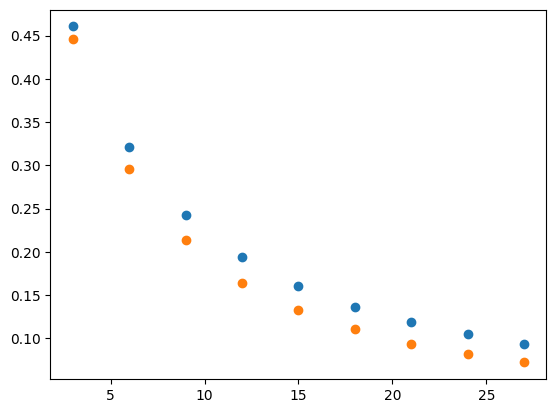

In [6]:
plt.scatter(timestamps, target(jnp.array([0.5, 20.0])))
plt.scatter(timestamps, reference(jnp.array([0.5, 20.0])))

In [7]:
A_grid, temperature_grid = jnp.linspace(0, 1, num=127), jnp.linspace(0, 100, num=129)
grid = jnp.stack(jnp.meshgrid(A_grid, temperature_grid, indexing='ij'), axis=-1)

In [8]:
target_grid = target(grid)
conversion = (target_grid[:, :, 0] - target_grid[:, :, -1])

reference_grid = reference(grid)
conversion_ref = (reference_grid[:, :, 0] - reference_grid[:, :, -1])

Text(0.5, 1.0, 'Reference (no inhib, no deg)')

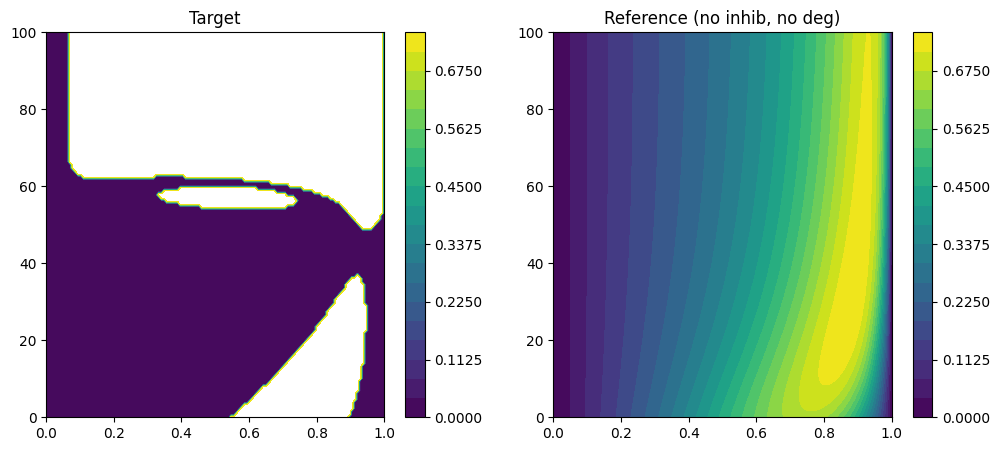

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
c = axes[0].contourf(A_grid, temperature_grid, jnp.abs(conversion.T - conversion_ref.T) > 0.05, levels=jnp.linspace(0, 0.75, num=21))
plt.colorbar(c, ax=axes[0])
axes[0].set_title('Target')

c = axes[1].contourf(A_grid, temperature_grid, conversion_ref.T, levels=jnp.linspace(0, 0.75, num=21))
plt.colorbar(c, ax=axes[1])
axes[1].set_title('Reference (no inhib, no deg)')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
c = axes[0].contourf(A_grid, temperature_grid, conversion.T, levels=jnp.linspace(0, 0.75, num=21))
plt.colorbar(c, ax=axes[0])
axes[0].set_title('Target')

c = axes[1].contourf(A_grid, temperature_grid, conversion_ref.T, levels=jnp.linspace(0, 0.75, num=21))
plt.colorbar(c, ax=axes[1])
axes[1].set_title('Reference (no inhib, no deg)')

In [ ]:
def combine(conditions, ts=None):
    return doe.utils.mesh(conditions, timestamps[:, None] if ts is None else ts[:, None])

rng = jax.random.PRNGKey(123)
rng, key_A, key_T = jax.random.split(rng, num=3)

n_train = 32
c_train = jnp.stack([
    jax.random.uniform(key_A, shape=(n_train, )),
    jax.random.uniform(key_T, minval=0.0, maxval=100.0, shape=(n_train, )),
], axis=-1)
y_train = target(c_train)
X_train = combine(c_train)

In [ ]:
SCALE0_A = 1.0
SCALE0_T = 50
SCALE0_t = 5

SCALE = jnp.array([SCALE0_A, SCALE0_T, SCALE0_t])
SIGMA0_W = 1.0

def rbf(scale, sigma):
    def kernel(x1, x2):
        d = (x1 - x2) / scale
        return sigma * jnp.exp(-jnp.sum(jnp.square(d), axis=-1))

    return kernel

In [ ]:
SCALE_A, SCALE_T, SCALE_t, SIGMA_W = doe.gp.GP.fit_kernel(
    init=np.array([SCALE0_A, SCALE0_T, SCALE0_t, SIGMA0_W]),
    bounds=[(0.0, None) for _ in range(4)],
    meta_kernel=lambda params: rbf(params[:3], params[-1]),
    X=X_train, y=y_train, noise=1.0e-6
)

In [ ]:
y_train.shape

In [ ]:
c = jnp.array([[1.0, 20.0]])
c_test2 = jnp.array([[1.0, 30.0]])
c_test3 = jnp.array([[0.75, 20.0]])

ts_test = jnp.linspace(0, 30, num=128)

obs = target(c)

X, y = combine(c, obs)
X_test1 = combine(c, ts=ts_test)
X_test2 = combine(c_test2, ts=ts_test)
X_test3 = combine(c_test3, ts=ts_test)

In [ ]:
state = gp.fit(X, y)
m1, s1 = gp.predict(state, X_test1)
m2, s2 = gp.predict(state, X_test2)
m3, s3 = gp.predict(state, X_test3)

std1, std2, std3 = jnp.sqrt(s1), jnp.sqrt(s2), jnp.sqrt(s3)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    axes[i].scatter(X[:, 2], y, color=plt.cm.tab10(0))
axes[0].fill_between(ts_test, m1 - std1, m1 + std1, color=plt.cm.tab10(0), alpha=0.5)
axes[1].fill_between(ts_test, m2 - std2, m2 + std2, color=plt.cm.tab10(1), alpha=0.5)
axes[2].fill_between(ts_test, m3 - std3, m3 + std3, color=plt.cm.tab10(2), alpha=0.5)

In [ ]:
As, temperatures = jnp.linspace(0, 1, num=31), jnp.linspace(0, 100, num=33)
possible = jnp.stack(jnp.meshgrid(As, temperatures, indexing='ij'), axis=-1)
possible = jnp.reshape(possible, shape=(-1, 2))

In [ ]:
MARGIN = SIGMA_NOISE

def acquisition(conditions, state):
    X = combine(conditions)
    mean, var = gp.predict(state, X)

    y_ref = reference(conditions)
    y_ref_ = jnp.reshape(y_ref, shape=(-1, ))

    acq = gp.bald(mean, var, y_ref_, MARGIN)
    acq = jnp.reshape(acq, shape=(-1, timestamps.shape[0]))
    acq = jnp.sum(acq, axis=-1)

    mean = jnp.reshape(mean, shape=(-1, timestamps.shape[0]))
    var = jnp.reshape(var, shape=(-1, timestamps.shape[0]))

    diff = np.mean(mean - y_ref, axis=-1)

    return diff, np.mean(var, axis=-1), acq

In [ ]:
diff, var, acq = acquisition(possible, state)

In [ ]:
acq = acq.reshape((As.shape[0], temperatures.shape[0]))
diff = diff.reshape((As.shape[0], temperatures.shape[0]))
var = var.reshape((As.shape[0], temperatures.shape[0]))

In [ ]:
error

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(6, 18))
axes[0].contourf(As, temperatures, acq.T)
axes[0].contour(A_grid, temperature_grid, (error - MARGIN).T, levels=[0.0], colors='black', zorder=1000)
axes[0].scatter(c_train[:, 0], c_train[:, 1], color='red')

c = axes[1].contourf(As, temperatures, jnp.abs(diff).T, levels=np.linspace(0.0, 1, num=21))
plt.colorbar(c, ax=axes[1])
axes[1].contour(As, temperatures, jnp.abs(diff).T, levels=[MARGIN], colors='black', zorder=1000)

c = axes[2].contourf(As, temperatures, np.sqrt(var).T)
plt.colorbar(c, ax=axes[2])
axes[2].contour(A_grid, temperature_grid, (error - MARGIN).T, levels=[0.0], colors='black', zorder=1000)